In [60]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import RidgeClassifier
from sklearn.metrics import accuracy_score, f1_score
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader

# Datasets

In [61]:
data_dict = pd.read_excel("../widsdatathon2025/Data Dictionary.xlsx")

In [62]:
data_train_category = pd.read_excel("../widsdatathon2025/TRAIN_NEW/TRAIN_CATEGORICAL_METADATA_new.xlsx")

data_train_quantative = pd.read_excel("../widsdatathon2025/TRAIN_NEW/TRAIN_QUANTITATIVE_METADATA_new.xlsx")

data_train_funct_matrix = pd.read_csv("../widsdatathon2025/TRAIN_NEW/TRAIN_FUNCTIONAL_CONNECTOME_MATRICES_new_36P_Pearson.csv")

data_train_solution = pd.read_excel("../widsdatathon2025/TRAIN_NEW/TRAINING_SOLUTIONS.xlsx")

In [63]:
data_test_category = pd.read_excel("../widsdatathon2025/TEST/TEST_CATEGORICAL.xlsx")

data_test_quantative = pd.read_excel("../widsdatathon2025/TEST/TEST_QUANTITATIVE_METADATA.xlsx")

data_test_funct_matrix = pd.read_csv("../widsdatathon2025/TEST/TEST_FUNCTIONAL_CONNECTOME_MATRICES.csv")

In [159]:
final_data_cat = pd.merge(data_train_category, data_train_quantative, on = 'participant_id')
final_data_mat = pd.merge(final_data_cat, data_train_funct_matrix, on = 'participant_id')
final_data_train = pd.merge(final_data_mat, data_train_solution, on = 'participant_id')
final_data_train

,participant_id,Basic_Demos_Enroll_Year,Basic_Demos_Study_Site,PreInt_Demos_Fam_Child_Ethnicity,PreInt_Demos_Fam_Child_Race,MRI_Track_Scan_Location,Barratt_Barratt_P1_Edu,Barratt_Barratt_P1_Occ,Barratt_Barratt_P2_Edu,Barratt_Barratt_P2_Occ,...,195throw_198thcolumn,195throw_199thcolumn,196throw_197thcolumn,196throw_198thcolumn,196throw_199thcolumn,197throw_198thcolumn,197throw_199thcolumn,198throw_199thcolumn,ADHD_Outcome,Sex_F
0,00aIpNTbG5uh,2019,4,1.0,0.0,3.0,21.0,45.0,NaN,NaN,...,-0.280312,0.037560,0.423037,0.242453,0.336213,0.402338,0.327915,0.539032,1,0
1,00fV0OyyoLfw,2017,1,0.0,9.0,2.0,21.0,0.0,21.0,45.0,...,-0.332783,-0.332711,0.556939,0.475578,0.429196,0.457970,0.312571,0.595978,1,0
2,04X1eiS79T4B,2017,1,1.0,2.0,2.0,9.0,0.0,NaN,NaN,...,-0.002132,-0.175586,0.679183,0.290292,0.486680,0.255208,0.575017,0.605182,0,1
3,05ocQutkURd6,2018,1,3.0,8.0,2.0,18.0,10.0,18.0,0.0,...,-0.199576,-0.216457,0.519074,0.298586,0.415466,0.511607,0.361204,0.446613,0,1
4,06YUNBA9ZRLq,2018,1,0.0,1.0,2.0,12.0,0.0,NaN,NaN,...,-0.141012,-0.002865,0.515169,0.336139,0.316430,0.442230,0.177079,0.378278,1,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1208,zwjJWCRzKhDz,2019,4,1.0,1.0,3.0,12.0,NaN,15.0,5.0,...,0.112789,0.211312,0.601190,0.587116,0.312695,0.485938,0.189102,0.354333,0,1
1209,zwXD5v17Rx01,2018,1,0.0,0.0,3.0,21.0,40.0,21.0,40.0,...,0.253990,0.198741,0.648260,0.055241,0.491985,0.118676,0.404331,0.537121,1,0
1210,zWzLCi3NTBTd,2018,3,2.0,3.0,3.0,21.0,40.0,21.0,35.0,...,0.044653,0.234887,0.538475,0.024265,0.472322,0.095624,0.205326,0.182633,1,1
1211,Zy9GTHDxUbXU,2019,4,0.0,1.0,3.0,18.0,35.0,18.0,45.0,...,-0.035955,-0.062152,0.706214,0.183288,0.104987,0.420463,0.152727,0.706737,1,0


In [160]:
final_data_cat = pd.merge(data_test_category, data_test_quantative, on = 'participant_id')
final_data_test = pd.merge(final_data_cat, data_test_funct_matrix, on = 'participant_id')
final_data_test

,participant_id,Basic_Demos_Enroll_Year,Basic_Demos_Study_Site,PreInt_Demos_Fam_Child_Ethnicity,PreInt_Demos_Fam_Child_Race,MRI_Track_Scan_Location,Barratt_Barratt_P1_Edu,Barratt_Barratt_P1_Occ,Barratt_Barratt_P2_Edu,Barratt_Barratt_P2_Occ,...,195throw_196thcolumn,195throw_197thcolumn,195throw_198thcolumn,195throw_199thcolumn,196throw_197thcolumn,196throw_198thcolumn,196throw_199thcolumn,197throw_198thcolumn,197throw_199thcolumn,198throw_199thcolumn
0,Cfwaf5FX7jWK,2022,4,0.0,0.0,4,21.0,30.0,18.0,30.0,...,0.080423,-0.054581,-0.088163,-0.028574,0.444847,0.350149,-0.012601,0.665750,0.560565,0.555732
1,vhGrzmvA3Hjq,2023,4,0.0,0.0,4,21.0,45.0,NaN,30.0,...,0.198009,-0.000724,0.083122,0.033043,0.687497,0.306229,0.717485,0.461809,0.559632,0.350027
2,ULliyEXjy4OV,2022,4,0.0,0.0,4,21.0,40.0,18.0,40.0,...,0.051319,0.023630,-0.056819,0.117396,0.576086,0.517831,0.527044,0.605038,0.609856,0.750987
3,LZfeAb1xMtql,2022,4,0.0,0.0,3,21.0,45.0,21.0,45.0,...,0.046183,-0.238962,0.121868,-0.260970,0.646818,0.594902,0.608156,0.595459,0.683189,0.542296
4,EnFOUv0YK1RG,2022,4,2.0,0.0,4,18.0,0.0,21.0,45.0,...,0.315734,0.002234,0.290791,0.344149,0.480214,0.539824,0.447322,0.293088,0.148529,0.539823
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
299,UadZfjdEg7eG,2023,4,0.0,0.0,4,18.0,0.0,18.0,35.0,...,0.021524,-0.162832,0.105546,0.028975,0.576180,0.378365,0.399277,0.556115,0.490833,0.568742
300,IUEHiLmQAqCi,2023,4,0.0,1.0,3,18.0,35.0,21.0,40.0,...,0.044974,-0.078047,-0.118271,0.035741,0.640073,0.515096,0.206462,0.536001,0.318518,0.305596
301,cRySmCadYFRO,2023,4,0.0,8.0,4,21.0,25.0,15.0,NaN,...,0.145582,0.004455,0.134574,-0.152951,0.782938,0.737555,0.593972,0.734463,0.680979,0.678973
302,E3MvDUtJadc5,2022,4,0.0,8.0,4,21.0,0.0,21.0,45.0,...,0.036169,-0.345563,-0.165280,-0.347035,0.657024,0.590523,0.094565,0.727339,0.429694,0.530238


In [179]:
from sklearn.impute import SimpleImputer
imputer = SimpleImputer(strategy='mean')

X = final_data_train[['SDQ_SDQ_Hyperactivity', 'SDQ_SDQ_Externalizing', 
                 'SDQ_SDQ_Difficulties_Total']]
y = final_data_train['ADHD_Outcome']


In [180]:
X_train, X_val, y_train, y_val = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

In [181]:
submission_val = pd.read_csv('../Submission_val.csv')
submission_val['ADHD_Outcome'] = y_val.reset_index()['ADHD_Outcome']
submission_val.to_csv('../Submission_val.csv', index=False)

In [182]:
X_test = final_data_test[['SDQ_SDQ_Hyperactivity', 'SDQ_SDQ_Externalizing', 
                 'SDQ_SDQ_Difficulties_Total']]

In [183]:
X_train = imputer.fit_transform(X_train)
X_val = imputer.transform(X_val)
X_test = imputer.transform(X_test)

In [184]:
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_val = scaler.transform(X_val)
X_test = scaler.transform(X_test)

# Model

In [185]:
X_test_tensor = torch.tensor(X_test, dtype=torch.float32)
X_train_tensor = torch.tensor(X_train, dtype=torch.float32)
X_val_tensor = torch.tensor(X_val, dtype=torch.float32)

y_train_tensor = torch.tensor(y_train.values, dtype=torch.float32)
y_val_tensor = torch.tensor(y_val.values, dtype=torch.float32)

In [186]:
class CustomDataset(Dataset):
    def __init__(self, X, y):
        self.X = X
        self.y = y

    def __len__(self):
        return len(self.y)
    
    def __getitem__(self, index):
        
        return (self.X[index], self.y[index])


dataset_train_sex = CustomDataset(X_train_tensor, y_train_tensor)
dataset_val_sex = CustomDataset(X_val_tensor, y_val_tensor)

#dataset_test_sex = CustomDataset(X_test, y_test)
#dataset_test   

In [187]:
Batch_Size = 64
dataloader_train = DataLoader(dataset_train_sex, batch_size=Batch_Size, shuffle=True)
dataloader_val = DataLoader(dataset_val_sex, batch_size=Batch_Size, shuffle=False)
#dataloader_test = DataLoader(dataset_test, batch_size=Batch_Size, shuffle=False)

In [232]:
from typing import Literal, Optional
import math
import random
class NeuralNetwork(nn.Module):
    def __init__(self, input_size, hidden_size, hidden_layer, output_size, hidden_size_changer : Literal['linear', 'fibonacci', 'logarit', 'random', 'increase_decrease'] | None = None, 
                 level_of_change : float = 1):
        super().__init__()
        
        # Set up layers
        layers = [
            nn.Linear(input_size, hidden_size),
            nn.Softplus()
        ]
                  
        if hidden_size_changer == 'increase_decrease':
            mid = hidden_layer // 2  # vị trí chuyển từ tăng sang giảm

            hidden_sizes = [hidden_size]

            # Giai đoạn tăng
            for i in range(1, mid + 1):
                next_size = int(hidden_sizes[-1] * level_of_change)
                hidden_sizes.append(next_size)

            # Giai đoạn giảm
            for i in range(mid + 1, hidden_layer + 1):
                next_size = max(1, int(hidden_sizes[-1] / level_of_change))  # tránh về 0
                hidden_sizes.append(next_size)

            # Tạo các hidden layers
            for i in range(hidden_layer):
                layers.append(nn.Linear(hidden_sizes[i], hidden_sizes[i + 1]))
                layers.append(nn.Tanh())  # hoặc ReLU

            # Output layer
            layers.append(nn.Linear(hidden_sizes[-1], output_size))

            

        else:
            for _ in range(hidden_layer - 1):
                layers.append(nn.Linear(hidden_size, hidden_size))
                layers.append(nn.Sigmoid())
            
            layers.append(nn.Linear(hidden_size, output_size))
            
        
        
        self.classifier = nn.Sequential(*layers)
        
        # # Initialize weights
        # for layer in self.classifier:
        #     if isinstance(layer, nn.Linear):
        #         nn.init.xavier_uniform_(layer.weight)
        #         if layer.bias is not None:
        #             nn.init.zeros_(layer.bias)

        # # Initialize weights
        # for layer in self.classifier:
        #     if isinstance(layer, nn.Linear):
        #         nn.init.kaiming_uniform_(layer.weight, nonlinearity='relu')  # or 'leaky_relu'
        #         if layer.bias is not None:
        #             nn.init.zeros_(layer.bias)
    
    def forward(self, X):
        output = self.classifier(X)
        return output

In [233]:
epochs = 300

input_size = X_train_tensor.shape[1]
hidden_size = 128
hidden_layer = 4
output_size = 1
model = NeuralNetwork(input_size, hidden_size, hidden_layer, output_size, hidden_size_changer = None, level_of_change = 2)

lr = 0.0005
optimizer = optim.Adam(model.parameters(), lr=lr)

criterion = nn.BCEWithLogitsLoss()
model

NeuralNetwork(
  (classifier): Sequential(
    (0): Linear(in_features=3, out_features=128, bias=True)
    (1): Softplus(beta=1.0, threshold=20.0)
    (2): Linear(in_features=128, out_features=128, bias=True)
    (3): Sigmoid()
    (4): Linear(in_features=128, out_features=128, bias=True)
    (5): Sigmoid()
    (6): Linear(in_features=128, out_features=128, bias=True)
    (7): Sigmoid()
    (8): Linear(in_features=128, out_features=1, bias=True)
  )
)

In [234]:
best_f1_val = 0.0
best_model_state = None

train_lossess = []
val_lossess = []
f1_train = []
f1_val = []

for epoch in range(epochs):
    train_loss = 0
    val_loss = 0

    y_train_label_pred = []
    y_train_label_true = []

    y_val_label_pred = []
    y_val_label_true = []

    # Training session
    model.train()
    for X_train, y_train in dataloader_train:
        optimizer.zero_grad()  # Reset gradients

        # Forward pass
        y_pred = model(X_train)

        # Compute loss
        loss = criterion(y_pred.squeeze(), y_train)
        train_loss += loss.item()

        # Predictions
        y_train_label_true.extend(y_train.tolist())
        y_train_label_pred.extend(torch.round(nn.Sigmoid()(y_pred)).tolist())

        # Backpropagation
        loss.backward()
        optimizer.step()

    train_loss /= len(dataloader_train)
    train_lossess.append(train_loss)

    f1_score_train = f1_score(y_train_label_true, y_train_label_pred)
    f1_train.append(f1_score_train)

    # Validation session
    model.eval()
    with torch.no_grad():
        for X_val, y_val in dataloader_val:
            y_pred = model(X_val)
            loss = criterion(y_pred.squeeze(), y_val)
            val_loss += loss.item()

            y_val_label_true.extend(y_val.tolist())
            y_val_label_pred.extend(torch.round(nn.Sigmoid()(y_pred)).tolist())

        val_loss /= len(dataloader_val)
        val_lossess.append(val_loss)

        f1_score_val = f1_score(y_val_label_true, y_val_label_pred)
        f1_val.append(f1_score_val)

        # Save best model based on validation F1 score
        if f1_score_val > best_f1_val:
            best_f1_val = f1_score_val
            best_model_state = model.state_dict()
            print(f"Epoch {epoch+1}: New best F1 on val = {f1_score_val:.4f}, saving model...")

# # After training, save the best model weights to a file
# torch.save(best_model_state, 'best_model.pth')
# print("Training complete. Best model saved as 'best_model.pth'")

Epoch 1: New best F1 on val = 0.8117, saving model...
Epoch 6: New best F1 on val = 0.8579, saving model...
Epoch 24: New best F1 on val = 0.8588, saving model...
Epoch 134: New best F1 on val = 0.8635, saving model...
Epoch 177: New best F1 on val = 0.8644, saving model...
Epoch 223: New best F1 on val = 0.8676, saving model...


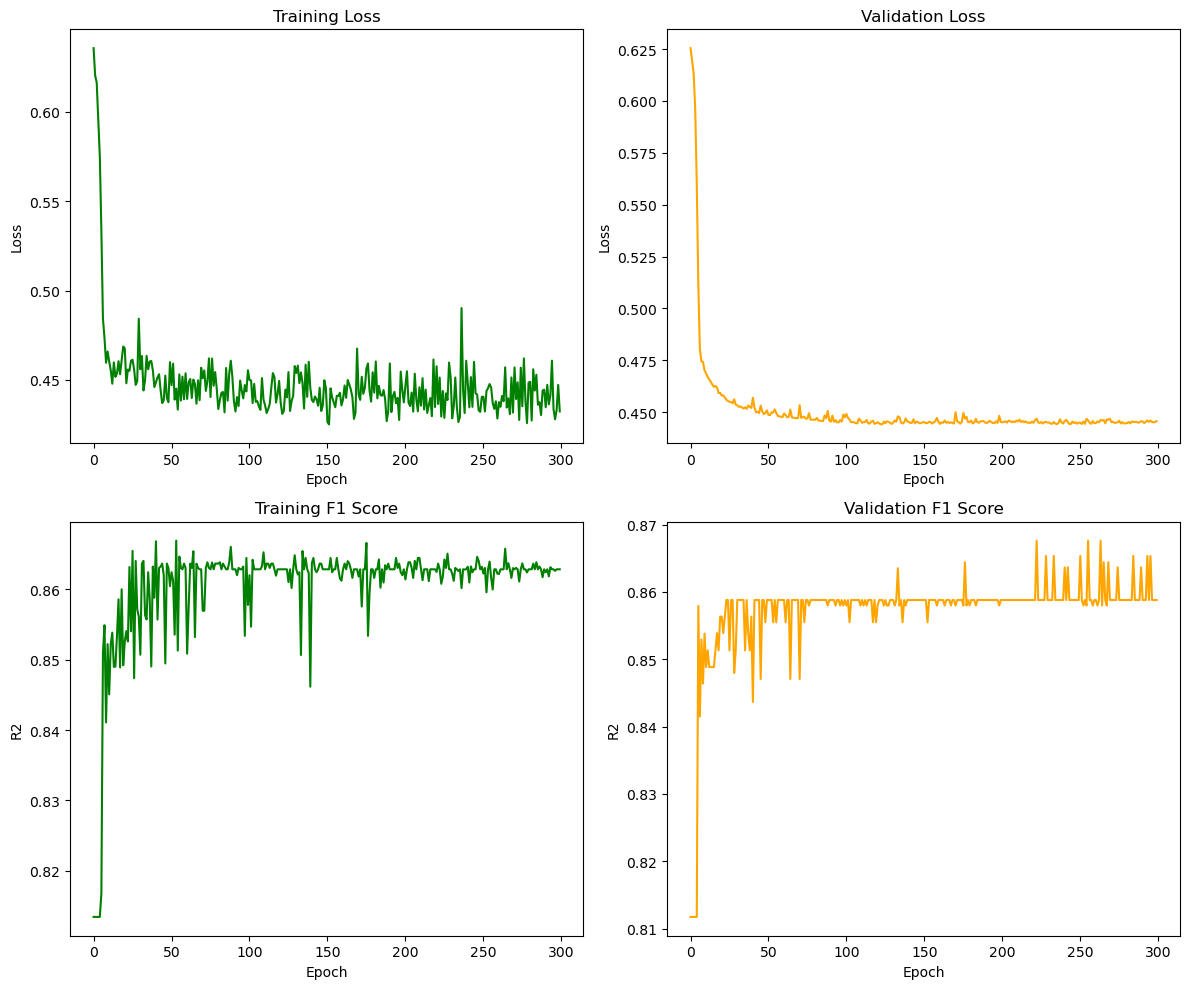

In [235]:
fig, ax = plt.subplots(2, 2, figsize=(12, 10))
ax[0, 0].plot(train_lossess, color='green')
ax[0, 0].set(xlabel='Epoch', ylabel='Loss')
ax[0, 0].set_title('Training Loss')

ax[0, 1].plot(val_lossess, color='orange')
ax[0, 1].set(xlabel='Epoch', ylabel='Loss')
ax[0, 1].set_title('Validation Loss')

ax[1, 0].plot(f1_train, color='green')
ax[1, 0].set(xlabel='Epoch', ylabel='R2')
ax[1, 0].set_title('Training F1 Score')

ax[1, 1].plot(f1_val, color='orange')
ax[1, 1].set(xlabel='Epoch', ylabel='R2')
ax[1, 1].set_title('Validation F1 Score')
plt.tight_layout()

plt.show()

In [236]:
torch.save(best_model_state, 'best_model_adhd.pth')
print("Training complete. Best model saved as 'best_model.pth'")

Training complete. Best model saved as 'best_model.pth'


In [237]:
best_model_state = torch.load('best_model_adhd.pth', map_location=torch.device('cpu'))
model.load_state_dict(best_model_state)

<All keys matched successfully>

For simulation

In [238]:
y_pred_adhd = model(X_val_tensor)
y_pred_adhd = torch.round(nn.Sigmoid()(y_pred_adhd))
y_pred_adhd = y_pred_adhd.detach().numpy()
y_pred_adhd = y_pred_adhd.flatten()
y_pred_adhd = y_pred_adhd.astype(int)
y_pred_adhd

array([0, 1, 0, 1, 1, 0, 0, 1, 0, 1, 1, 1, 0, 1, 1, 1, 0, 1, 1, 1, 1, 1,
       1, 1, 1, 0, 0, 1, 0, 0, 0, 0, 1, 1, 1, 1, 0, 1, 1, 0, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 0, 0, 1, 1, 0, 0, 1, 1, 1, 1, 1, 1, 0, 0, 0, 0,
       1, 0, 1, 1, 0, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 0, 1, 1, 1, 1, 0, 1,
       1, 0, 0, 0, 1, 0, 1, 1, 1, 0, 1, 1, 1, 0, 1, 0, 1, 1, 1, 0, 0, 0,
       1, 1, 1, 1, 1, 1, 0, 0, 0, 1, 1, 1, 0, 1, 1, 1, 1, 1, 0, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 0, 0, 1, 1, 1, 1, 0, 1, 0, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 0, 1, 0, 1, 1, 1, 1, 1, 1, 1, 0, 1, 1,
       1, 1, 1, 1, 1, 0, 1, 0, 1, 1, 0, 1, 1, 0, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 0, 1, 0, 1, 1, 1, 1, 0, 1, 1, 1, 1, 1, 1, 1, 0, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 0, 0, 0, 1, 0, 1, 1, 1, 1, 1, 1, 1, 1,
       0])

In [239]:
submission_simulation = pd.read_csv('../Submission_pred.csv')
submission_simulation['ADHD_Outcome'] = y_pred_adhd
submission_simulation.to_csv('../Submission_pred.csv', index=False)

For test

In [240]:
y_pred = model(X_test_tensor)
y_pred
nn.Sigmoid()(y_pred)
y_pred = torch.round(nn.Sigmoid()(y_pred))
y_pred = y_pred.detach().numpy()
y_pred = y_pred.flatten()
y_pred = y_pred.astype(int)
y_pred

array([1, 0, 1, 1, 1, 1, 1, 0, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 0, 1, 1, 1,
       1, 1, 1, 0, 0, 1, 0, 1, 1, 1, 1, 1, 0, 1, 1, 1, 1, 1, 0, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 0, 1, 1, 0, 1, 1, 0, 1, 0, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 0, 1, 0, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 0, 1, 1,
       1, 0, 1, 0, 0, 1, 1, 1, 1, 1, 1, 0, 1, 1, 1, 1, 1, 0, 1, 0, 1, 1,
       1, 1, 0, 1, 0, 0, 1, 1, 1, 1, 1, 1, 1, 1, 1, 0, 0, 1, 0, 1, 1, 1,
       1, 1, 0, 1, 1, 1, 1, 1, 1, 1, 1, 1, 0, 1, 0, 0, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 0, 1, 0, 1, 1, 1, 1, 1, 1, 1, 1, 1, 0, 1, 1, 0, 1, 1,
       1, 1, 1, 1, 0, 0, 0, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 0,
       0, 1, 1, 1, 1, 0, 0, 0, 0, 1, 1, 1, 0, 1, 1, 1, 0, 1, 1, 0, 1, 0,
       0, 0, 0, 1, 1, 1, 0, 1, 1, 1, 1, 1, 1, 1, 1, 1, 0, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 0, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 0, 1, 1, 1, 1, 1,
       0, 1, 1, 1, 1, 0, 1, 1, 0, 0, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       0, 0, 1, 1, 1, 1, 1, 1, 1, 0, 1, 1, 0, 1, 1,

In [242]:
submission = pd.read_csv('submission-ThuyDuc.csv')

In [243]:
submission['ADHD_Outcome'] = y_pred
submission.to_csv('submission-ThuyDuc.csv', index=False)